# Functional isoform metrics across cell types and tissues


In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

# Relocation-proof bootstrap: chdir to the notebooks/ root (marked by .notebooks_root)
import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root"))
         else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")

import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse, csr_matrix
from scipy.stats import kruskal
sys.path.insert(0, os.getcwd())              # notebooks/ root -> add_classification
from add_classification import add_classification

BASEDIR = "./../pacbio"
H5AD    = f"{BASEDIR}/h5ads/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad"
CLS     = "./../csvs/all_samples_recollapsed_sqanti3_classification.csv"
FIGDIR  = "figures"
CSVDIR  = "./../csvs"
os.makedirs(FIGDIR, exist_ok=True)

# ---- knobs ----
PLOT_KIND = "violin"   # "violin" (inner box) or "box"
MIN_CELLS = 20         # drop cell types / tissues with fewer cells than this
MAX_PLOT  = 40000      # subsample cells for rendering each figure (viz only)
COLOR     = "#4c72b0"
METRICS = [("novel","Novel (NIC/NNC)"), ("coding","Coding"), ("nmd","Predicted NMD"),
           ("ir","Intron retention"), ("es","Exon skipping\n(exons < ref)")]

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP

print("setup done")

setup done


In [2]:
# preferred plot formatting
TICK_LEN, TICK_PAD, LABEL_PAD, TITLE_PAD = 2.0, 1.5, 1.5, 3.0
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"]  = 42
matplotlib.rcParams["font.family"]  = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"] + matplotlib.rcParams["font.sans-serif"]
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "figure.titlesize": 6, "axes.labelweight": "bold", "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_PAD, "ytick.major.pad": TICK_PAD, "axes.labelpad": LABEL_PAD,
    "savefig.dpi": 300, "savefig.bbox": "tight",
})

## 1. Load pbids object + merge SQANTI3 classification

In [3]:
adata = sc.read_h5ad(H5AD)
from add_classification import add_classification
add_classification(adata, "./../csvs/all_samples_recollapsed_pigeon_classification.csv",
                   isoform_col="molecule_id", prefix="pigeon_", sep=",")
print(f"{adata.shape[0]:,} cells x {adata.shape[1]:,} isoforms")
if not issparse(adata.X):
    adata.X = csr_matrix(adata.X)

add_classification(
    adata, CLS,
    columns=["structural_category", "subcategory", "coding", "predicted_NMD",
             "exons", "ref_exons", "associated_gene"],
    isoform_col="molecule_id", prefix="sqanti_", sep=",",
)

if "tissue" not in adata.obs.columns:
    parts = adata.obs.index.str.split("_")
    adata.obs["tissue"] = ["_".join(p[1:]) if len(p) > 1 else "unknown" for p in parts]
print("tissues:", adata.obs["tissue"].nunique(), "| broad cell classes:", adata.obs["broad_cell_class"].nunique())

203,311 cells x 854,410 isoforms
tissues: 26 | broad cell classes: 34


## 2. Per-isoform feature masks

In [4]:
var = adata.var
scat = var["pigeon_structural_category"].astype(str).str.lower()
masks = {
    "novel":  scat.isin(["novel_in_catalog", "novel_not_in_catalog"]).values,
    "coding": var["sqanti_coding"].astype(str).str.lower().eq("coding").values,
    "nmd":    var["sqanti_predicted_NMD"].astype(str).str.upper().eq("TRUE").values,
    "ir":     var["sqanti_subcategory"].astype(str).str.contains("intron_retention", case=False, na=False).values,
}
_e = pd.to_numeric(var["sqanti_exons"], errors="coerce")
_r = pd.to_numeric(var["sqanti_ref_exons"], errors="coerce")
masks["es"] = ((_e < _r) & _e.notna() & _r.notna()).values
for k, m in masks.items():
    print(f"  mask {k:7s}: {int(m.sum()):>8,} / {len(m):,} isoforms")

  mask novel  :  320,724 / 854,410 isoforms
  mask coding :  594,361 / 854,410 isoforms
  mask nmd    :   37,455 / 854,410 isoforms
  mask ir     :   65,375 / 854,410 isoforms
  mask es     :  406,936 / 854,410 isoforms


## 3. Per-cell metric fractions

In [5]:
X = adata.X
tot = np.asarray(X.sum(axis=1)).ravel().astype(float)
cell_df = adata.obs[["donor", "broad_cell_class", "cell_ontology_class", "tissue"]].astype(str).copy()
for key, mask in masks.items():
    feat = np.asarray(X[:, mask].sum(axis=1)).ravel().astype(float)
    cell_df[key] = np.divide(feat, tot, out=np.zeros_like(feat), where=tot > 0)
cell_df["_tot"] = tot
cell_df = cell_df[(cell_df["broad_cell_class"] != "unknown") & (cell_df["_tot"] > 0)].copy()
print(f"{len(cell_df):,} cells kept")
cell_df.head()

203,311 cells kept


,donor,broad_cell_class,cell_ontology_class,tissue,novel,coding,nmd,ir,es,_tot
CGCAACTCTAGTCTCA-1_T66,TSP10,myeloid leukocyte,monocyte,Blood,0.064040,0.729495,0.016162,0.190909,0.244040,4950.0
GACCAGCTGTGGGACA-1_T66,TSP10,erythroid lineage cell,erythrocyte,Blood,0.007989,0.958274,0.002710,0.017475,0.030528,14020.0
GGGTGTCTGACATCGT-1_T66,TSP10,myeloid leukocyte,classical monocyte,Blood,0.053240,0.698844,0.019091,0.150040,0.283410,3719.0
TAGGCCGACAGCTTGT-1_T66,TSP10,myeloid leukocyte,classical monocyte,Blood,0.051567,0.749039,0.018200,0.155308,0.242669,4945.0
TGCCGGATGTCATTTC-1_T66,TSP10,myeloid leukocyte,monocyte,Blood,0.063744,0.767960,0.024283,0.187184,0.309612,2965.0


In [6]:
# save per-cell fractions + per-category summary
keep_cols = ["donor", "broad_cell_class", "cell_ontology_class", "tissue"] + [k for k, _ in METRICS]
cell_df[keep_cols].to_csv(f"{CSVDIR}/03_singlecell_functional_metric_fractions_per_cell.csv")
rows = []
for gcol in ["broad_cell_class", "tissue"]:
    g = cell_df.groupby(gcol, observed=True)
    n = g.size().rename("n_cells")
    for key, lab in METRICS:
        t = pd.concat([g[key].mean().rename("mean_frac"), n], axis=1).reset_index()
        t.insert(0, "metric", key); t.insert(0, "grouping", gcol)
        rows.append(t.rename(columns={gcol: "category"}))
pd.concat(rows, ignore_index=True).to_csv(f"{CSVDIR}/03_singlecell_functional_metric_summary.csv", index=False)
print("wrote per-cell + summary CSVs")

wrote per-cell + summary CSVs


## 4. Plot: violin panels (one per metric) across categories

In [11]:
def make_figure(cell_df, group_col, figsize=None):
    vc = cell_df[group_col].value_counts()
    cats = [c for c in vc.index if vc[c] >= MIN_CELLS and c != "unknown"]
    if not cats:
        print(f"[skip] no {group_col} categories with >= {MIN_CELLS} cells"); return
    # one fixed category order (descending mean novel fraction) shared by all panels
    order = (cell_df[cell_df[group_col].isin(cats)]
             .groupby(group_col)["novel"].mean().sort_values(ascending=False).index.tolist())
    sub = cell_df[cell_df[group_col].isin(order)]
    if len(sub) > MAX_PLOT:
        sub = sub.sample(MAX_PLOT, random_state=0)
    n = len(order)
    if figsize is None:
        figsize = (1.7 * len(METRICS), max(3.0, 0.16 * n))   # horizontal: metrics as columns
    # horizontal (flipped): categories on the y-axis, metric fraction on the x-axis, metrics side by side
    fig, axes = plt.subplots(1, len(METRICS), sharey=True, figsize=figsize)
    for ax, (key, lab) in zip(axes, METRICS):
        if PLOT_KIND == "box":
            sns.boxplot(data=sub, y=group_col, x=key, order=order, ax=ax,
                        color=COLOR, fliersize=0, linewidth=0.4)
        else:
            sns.violinplot(data=sub, y=group_col, x=key, order=order, ax=ax,
                           inner="box", cut=0, linewidth=0.25, color=COLOR)
        ax.set_xlabel(lab, fontweight="bold"); ax.set_ylabel(""); ax.set_xlim(0, None)
        groups = [g[key].values for _, g in sub.groupby(group_col, observed=True) if len(g) >= MIN_CELLS]
        if len(groups) >= 2:
            try:
                _, p = kruskal(*groups)
                ax.text(0.97, 0.995, f"KW p={p:.1e}", transform=ax.transAxes,
                        ha="right", va="top", fontsize=5)
            except ValueError:
                pass
    axes[0].set_ylabel(group_col.replace("_", " ").title(), fontweight="bold")
    fig.suptitle(f"Per-cell functional isoform metrics by {group_col.replace('_', ' ')}", fontweight="bold")
    out = figpath(f"03_singlecell_functional_metrics_by_{group_col}.pdf")
    fig.savefig(out, bbox_inches="tight", dpi=300)
    print(f"saved {out}  ({n} categories, {len(sub):,} cells plotted)")
    return fig

### 4a. All cell types side by side

saved figures/03_singlecell_functional_metrics_by_broad_cell_class.pdf  (34 categories, 40,000 cells plotted)


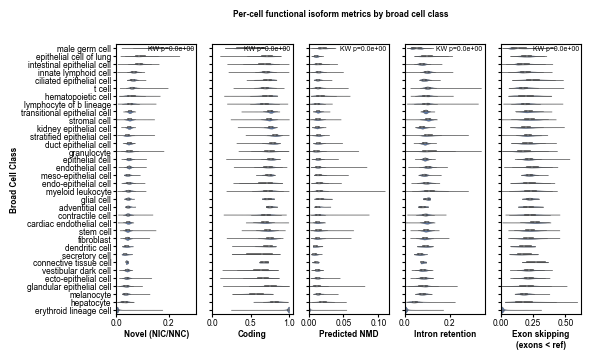

In [16]:
_ = make_figure(cell_df, "broad_cell_class", figsize=(6.0, 3.5))
plt.show()

### 4b. All tissues side by side

saved figures/03_singlecell_functional_metrics_by_tissue.pdf  (26 categories, 40,000 cells plotted)


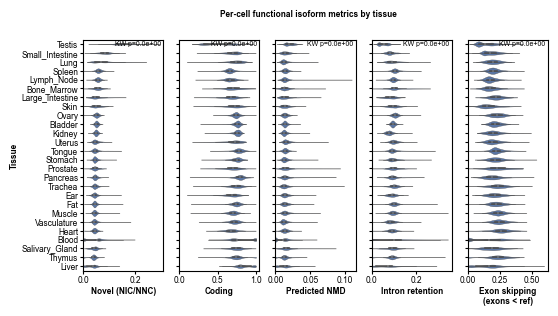

In [15]:
_ = make_figure(cell_df, "tissue", figsize=(6.0, 3.0))
plt.show()